# 項目實戰：Marketing A/B Testing
狀況： 某公司想要測試新的廣告頁面（Landing Page）是否能提升轉換率（Conversion Rate）？

目標： 判斷「新頁面（廣告組 AD）」是否顯著優於「舊頁面（公益廣告/對照組 PSA）」，進而決定是否要全面上線

## 1. 導入數據庫

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from scipy.stats import chi2_contingency

from matplotlib import rcParams
rcParams['font.sans-serif'] = ['STHeiti']

marketing = pd.read_csv('data/resume data/marketing_A:B_Testing.csv')
marketing

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [2]:
print('總紀錄數：', marketing.count()) # 查看數據數
print('字段數量：', len(marketing.columns)) # 查看欄位字段數量

marketing.info()
marketing.head()
marketing.tail()

總紀錄數： Unnamed: 0       588101
user id          588101
test group       588101
converted        588101
total ads        588101
most ads day     588101
most ads hour    588101
dtype: int64
字段數量： 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23
588100,588100,1237779,ad,False,1,Tuesday,23


## 2. 資料清理、檢查數據（重複值處理、重複暴露檢查）

In [3]:
marketing.duplicated().sum()
marketing.drop_duplicates(inplace=True) # 若有重複值的話刪除

print(len(marketing))

588101


In [4]:
# 檢查是否有同一用戶出現在不同組別（確保決策不被污染，以維持檢定準確性
# 根據 user id 分組，計算 test group 的不重複數量
user_group_check = marketing.groupby('user id')['test group'].nunique()

In [5]:
# 找出不重複數量大於 1 的用戶（也就是重複暴露用戶）
polluted_users = user_group_check[user_group_check > 1].count()
print(f'同時出現在兩組的用戶數量：{polluted_users}')

同時出現在兩組的用戶數量：0


In [6]:
# 如果 polluted_users > 0，將其剔除
if polluted_users > 0:
    # 找出乾淨的用戶 ID
    clean_user_ids = user_group_check[user_group_check == 1].index
    marketing = marketing[marketing['user id'].isin(clean_user_ids)]
    print('已剔除重複暴露用戶')

## 3. 指標計算（計算 test group（ad、psa）的樣本數、轉換率

In [7]:
# 計算 ad、psa 兩組的樣本數
group_counts = marketing['test group'].value_counts()
print('樣本分佈：\n', group_counts)

樣本分佈：
 test group
ad     564577
psa     23524
Name: count, dtype: int64


In [8]:
# 計算兩組的轉換率（將絕對數量轉換成比例，以達到較爲公平的基準判斷[適用於商業溝通
# (converted 是 bool，可以直接算 mean)
# True = 1，False = 0
conversion_rates = marketing.groupby('test group')['converted'].mean()

print('\n各組轉換率：')
print(conversion_rates)


各組轉換率：
test group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


In [9]:
# 計算兩組的轉換人數（實際完成轉換的絕對人數[適用於統計模型
# 因此方便後續用於卡方檢定
conversion_sums = marketing.groupby('test group')['converted'].sum()
print('\n各組轉換人數：')
print(conversion_sums)


各組轉換人數：
test group
ad     14423
psa      420
Name: converted, dtype: int64


雖然兩組樣本數不平衡（96% vs 4%），但由於對照組 (psa) 的絕對樣本數已達 23,524 筆，且觀察到的轉換人數 (420) 遠大於 5

根據中央極限定理，這足以支撐 Z-檢定的準確性，不至於產生偏差。

## 4. 統計檢定 (Statistical Testing)
### I. Z-檢定（Z-test for Proportions）
專門用於檢定「兩個大樣本獨立母體的比例（轉換率）」是否有顯著差異

- 虛無假設 H_0：p_(ad) = p_(psa)（廣告對轉換率沒有影響）
- 對立假設 H_1：p_(ad) ≠ p_(psa)（廣告對轉換率有顯著影響）

In [10]:
conversions = [14423, 420] # 轉換人數 [ad, psa]
nobs = [564577, 23524]     # 總樣本數 [ad, psa]

# 執行 Z-檢定 (雙尾檢定)
z_stat, p_val = proportions_ztest(conversions, nobs)

# 計算 95% 信賴區間
(lower_ad, lower_psa), (upper_ad, upper_psa) = proportion_confint(conversions, nobs, alpha=0.05)

print(f'Z-statistic: {z_stat:.2f}')
print(f'P-value: {p_val:.10f}')
print(f'廣告組 95% 信賴區間：[{lower_ad:.4f}, {upper_ad:.4f}]')
print(f'對照組 95% 信賴區間：[{lower_psa:.4f}, {upper_psa:.4f}]')

Z-statistic: 7.37
P-value: 0.0000000000
廣告組 95% 信賴區間：[0.0251, 0.0260]
對照組 95% 信賴區間：[0.0162, 0.0195]


#### A. 統計檢定結果
經由 Z-test 檢定，得到 P-value<0.001（遠小於 α=0.05），因此有足夠的證據拒絕虛無假設 H_0：p_(ad) = p_(psa)

說明廣告（AD）組與對照組（PSA）的轉換率存在顯著差異

#### B. 效應量與信賴區間（應數專業亮點）
廣告組的轉換率為 2.55%，相較於對照組的 1.79%，達到了 43% 的相對提升 (Relative Lift)

此外，兩組的 95% 信賴區間完全沒有重疊（[0.0251, 0.0260] vs. [0.0162, 0.0195]），這進一步證實了實驗結果的穩定性

#### C. 商業決策建議
實驗證明該廣告方案能有效驅動用戶轉換

考量到廣告組在大樣本下依然維持穩定的高轉換率，建議公司可以全面投放該廣告方案，以取代現有的公益廣告投放

預計每 10,000 次曝光可增加約 76 次轉換

### II. 卡方檢定（Chi-square Test）
用來檢定兩個類別變數（「廣告類型」與「是否轉換」）之間是否相互獨立

這能從另一個角度（次數分佈）驗證廣告類別是否真的會影響轉換結果

- 虛無假設 H_0：p_(ad) = p_(psa)（廣告對轉換率沒有影響）
- 對立假設 H_1：p_(ad) ≠ p_(psa)（廣告對轉換率有顯著影響）

In [11]:
# 建立列聯表 [ [轉換人數, 未轉換人數], [轉換人數, 未轉換人數] ]
# AD 組: 轉換 14423, 未轉換 564577 - 14423 = 550154
# PSA 組: 轉換 420, 未轉換 23524 - 420 = 23104
table = np.array([[14423, 550154], 
                  [420, 23104]])

# 執行卡方檢定
# chi2: 卡方統計值, p: p-value, dof: 自由度, expected: 期望次數
chi2, p, dof, expected = chi2_contingency(table)

print(f'Chi-square statistic: {chi2:.2f}')
print(f'P-value: {p:.10f}')

Chi-square statistic: 54.01
P-value: 0.0000000000


#### A. 統計檢定摘要 (Technical Summary)
採用 Pearson 卡方檢定 (Chi-square Test of Independence) 進行驗證：

廣告組（Treatment）與對照組（Control）在轉換表現上是否具有統計學上的顯著差異

檢定統計量（χ2）：54.01

自由度（df）：1

P-value：< 0.00001

由於 P-value 遠小於顯著水準 α=0.05

有極強的證據拒絕虛無假設 H_0：p_(ad) = p_(psa)

判定廣告類型與用戶是否轉換並非相互獨立，而是具有顯著的相關性

#### B. 觀察值與期望值分析 (Insight into Expected Values)
進一步觀察列聯表（Contingency Table），廣告組（Ad）的實際轉換人數顯著高於統計上的期望值

這說明了廣告組並非僅僅是因為樣本數大而導致轉換人數多，其轉換效率在統計學上確實優於 PSA（公益廣告）組

#### C. 綜合評估與建議 (Actionable Insights)

結合 Z-檢定 與 卡方檢定 的雙重驗證，結果一致指向廣告方案的有效性

穩定性：大樣本容量（N=588,101）下，χ2 = 54.01 顯示了極強的效應量（Effect Size），說明結果並非偶然

『決策建議：由於廣告組帶來的轉換率提升幅度顯著且穩定，建議將行銷資源從 PSA 轉向 Ad 方案，以最大化投資報酬率（ROI）』

## 5. 圖表可視化

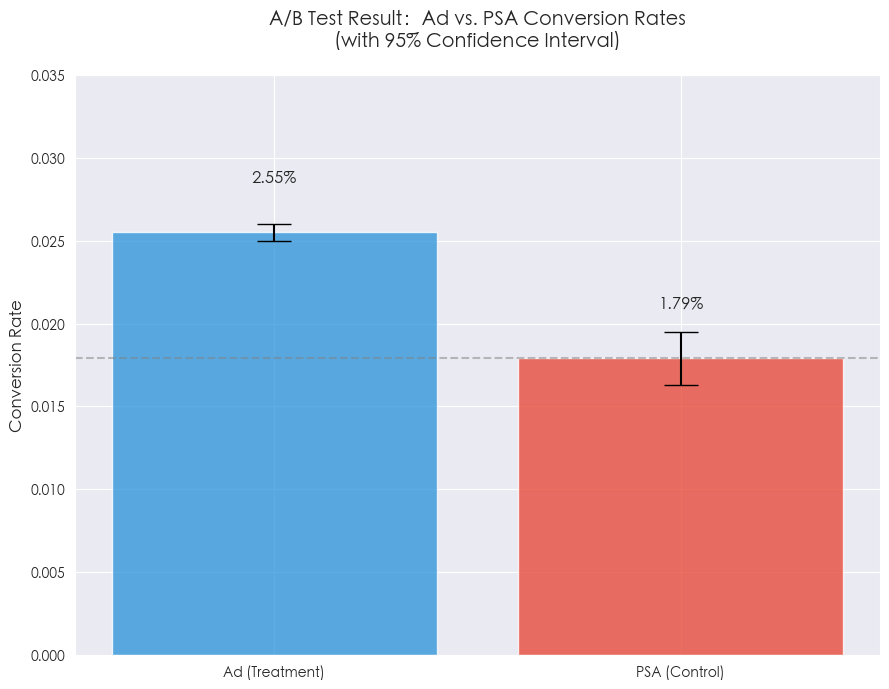

In [13]:
groups = ['Ad (Treatment)', 'PSA (Control)']
rates = [0.0255, 0.0179]
# 根據你算出的信賴區間計算誤差範圍（Error Bars，信賴區間與平均值的差值）
errors = [0.0260 - 0.0255, 0.0195 - 0.0179]

plt.figure(figsize=(9, 7))
plt.bar(groups, rates, yerr=errors, capsize=12, color=['#3498db', '#e74c3c'], alpha=0.8)
plt.axhline(y=0.0179, color='gray', linestyle='--', alpha=0.5)

plt.ylabel('Conversion Rate', fontsize=12)
plt.title('A/B Test Result：Ad vs. PSA Conversion Rates\n(with 95% Confidence Interval)', fontsize=14, pad=20)
plt.ylim(0, 0.035)

for i, v in enumerate(rates):
    plt.text(i, v + 0.003, f'{v:.2%}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

透過這張帶有 Error Bars的長條圖可以發現：兩組轉換率的巨大落差

最關鍵的是，代表信賴區間的白線（Error Bars 誤差棒）彼此沒有上下交疊

直觀的呈現了統計檢定的結果 —— 即使考慮到抽樣誤差，廣告組的表現依然穩穩地贏過對照組